## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

df_train = pd.read_csv("emnist-letters-train.csv",header=None)
df_test = pd.read_csv("emnist-letters-test.csv",header=None)

## Loading Data

In [3]:
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]

X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

X_train = X_train.to_numpy(dtype=int)
X_test = X_test.to_numpy(dtype=int)

## Normalizing Data


In [4]:
mu = np.mean(X_train)
sigma = np.std(X_train)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

X_train_norm = X_train_norm.reshape(-1, 28,28).swapaxes(1,2)
X_test_norm = X_test_norm.reshape(-1,28,28).swapaxes(1,2)

y_train-=1
y_test-=1

## Creating Layers


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    tf.keras.layers.Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    tf.keras.layers.Dense(32, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    tf.keras.layers.Dense(26, activation='softmax')
    
])

## Compiling and fiting the layers 

In [28]:
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.000001),
    metrics=['accuracy']

)

In [29]:

model.fit(X_train_norm, y_train, epochs=10)

Epoch 1/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9738 - loss: 0.1736
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1736
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1735
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9739 - loss: 0.1735
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9739 - loss: 0.1735
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9737 - loss: 0.1735
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1735
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1735
Epoch 9/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1734
Epoch 10/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9738 - loss: 0.1734


## Model's Accuracy

In [60]:
accuracy = model.evaluate(X_train_norm, y_train, verbose=0)[1]
print(f"Model's train set accuracy: {accuracy*100:.2f}%")

accuracy = model.evaluate(X_test_norm, y_test, verbose=0)[1]
print(f"Model's test set accuracy: {accuracy*100:.2f}%")

Model's train set accuracy: 97.38%
Model's test set accuracy: 90.45%


## Testing on a Custom Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Lettes is: "A"


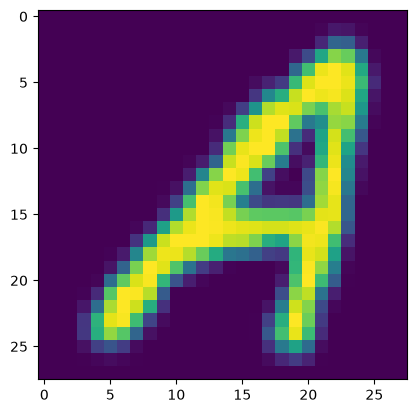

In [61]:
from PIL import Image

img = Image.open("img1.png").convert("L")
img = img.resize((28,28))
img_arr = np.array(img, dtype=int)

img_arr = img_arr.reshape(-1, 28, 28)


img_norm = (img_arr - mu) / sigma

img_norm = img_norm.reshape(-1, 28, 28)


pred = model.predict(img_norm)

letter_index = np.argmax(pred)

letter = chr(letter_index + 1 + 64)



plt.imshow(img)
print(f'Lettes is: "{letter}"')